In [7]:
from pathlib import Path
import platform
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    auc,
    precision_recall_fscore_support,
)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42

FIG_DIR = Path("figures")
ARTIFACT_DIR = Path("artifacts")

FIG_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.precision", 3)

np.set_printoptions(precision=3, suppress=True)

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.05,
)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
})

print(f"Python {sys.version.split()[0]}")
print(f"scikit-learn {sklearn.__version__}")
print(f"Platform: {platform.platform()}")

Python 3.13.9
scikit-learn 1.7.2
Platform: Windows-11-10.0.26200-SP0


In [9]:
from sklearn.datasets import load_digits
import pandas as pd

digits = load_digits()

X = digits.data
y = digits.target
images = digits.images
class_names = digits.target_names
class_counts = pd.Series(y).value_counts().sort_index()

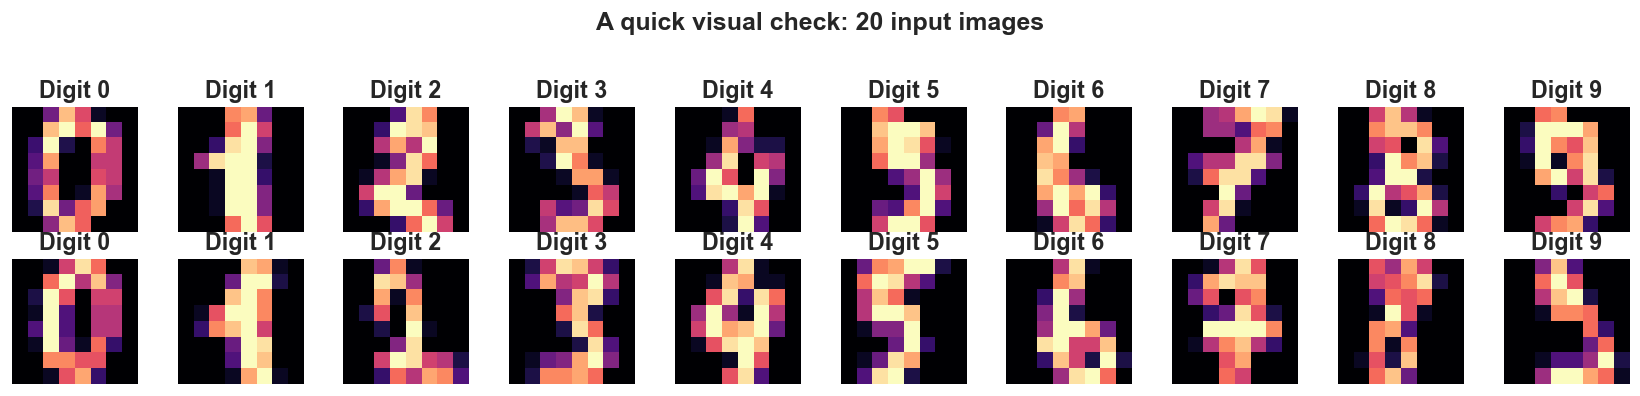

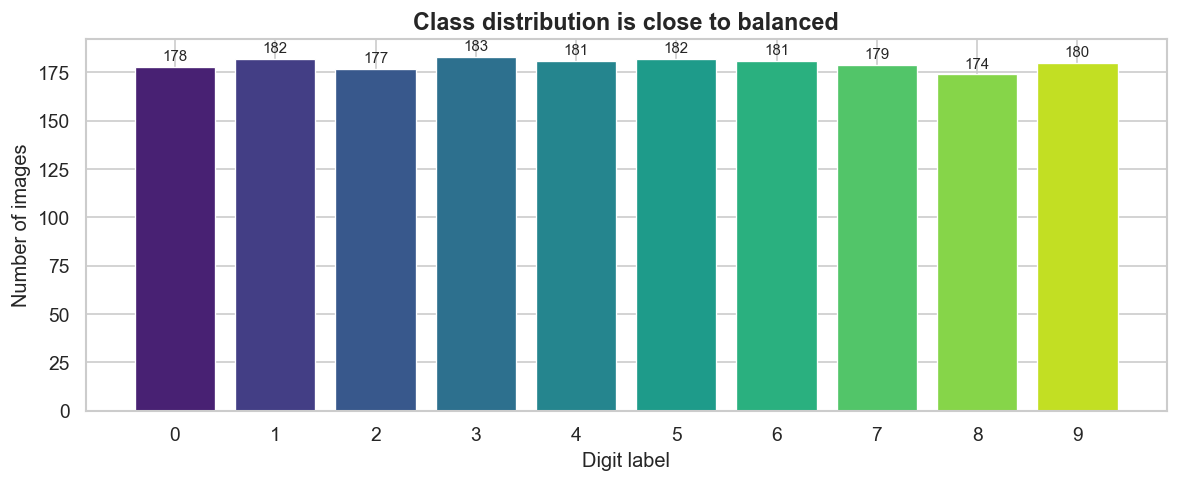

In [10]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3.2))
for ax, image, label in zip(axes.ravel(), images[:20], y[:20]):
    ax.imshow(image, cmap="magma", interpolation="nearest")
    ax.set_title(f"Digit {label}")
    ax.axis("off")
fig.suptitle("A quick visual check: 20 input images", y=1.03, fontsize=15, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_sample_digits.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.2))
colors = sns.color_palette("viridis", n_colors=10)
ax.bar(class_counts.index.astype(str), class_counts.values, color=colors, edgecolor="white", linewidth=0.8)
ax.set(title="Class distribution is close to balanced", xlabel="Digit label", ylabel="Number of images")
ax.bar_label(ax.containers[0], padding=2, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_class_distribution.png", bbox_inches="tight")
plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

split_summary = pd.DataFrame(
    {
        "partition": ["Training / cross-validation", "Held-out test"],
        "images": [len(y_train), len(y_test)],
        "share": [f"{len(y_train) / len(y):.1%}", f"{len(y_test) / len(y):.1%}"],
    }
)
display(split_summary)
assert set(np.unique(y_train)) == set(np.unique(y_test)) == set(np.unique(y))

,partition,images,share
0,Training / cross-validation,1437,80.0%
1,Held-out test,360,20.0%


In [13]:
models = {
    "Logistic regression": Pipeline(
        steps=[
            ("standardize", StandardScaler()),
            ("classifier", LogisticRegression(C=3.0, max_iter=4000, solver="lbfgs", random_state=RANDOM_STATE)),
        ]
    ),
    "Random forest": Pipeline(
        steps=[
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=300,
                    max_features="sqrt",
                    n_jobs=1,
                    random_state=RANDOM_STATE,
                ),
            )
        ]
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro",
    "roc_auc": "roc_auc_ovr",
}

cv_rows = []
for model_name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1, return_train_score=False)
    row = {"model": model_name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std(ddof=1)
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).sort_values(
    ["roc_auc_mean", "f1_mean"], ascending=False, ignore_index=True
)
cv_display = cv_results[["model"] + [f"{m}_mean" for m in scoring]].copy()
for metric in scoring:
    cv_display[metric + "_mean"] = cv_display[metric + "_mean"].map("{:.4f}".format)
cv_display.columns = ["Model", "Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)", "ROC-AUC (OvR macro)"]
display(cv_display)

cv_results.to_csv(ARTIFACT_DIR / "cross_validation_results.csv", index=False)
selected_model_name = cv_results.loc[0, "model"]
print(f"Selected from cross-validation: {selected_model_name}")

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),ROC-AUC (OvR macro)
0,Random forest,0.9749,0.9756,0.9748,0.9748,0.9994
1,Logistic regression,0.9708,0.9719,0.9707,0.9707,0.9990


Selected from cross-validation: Random forest


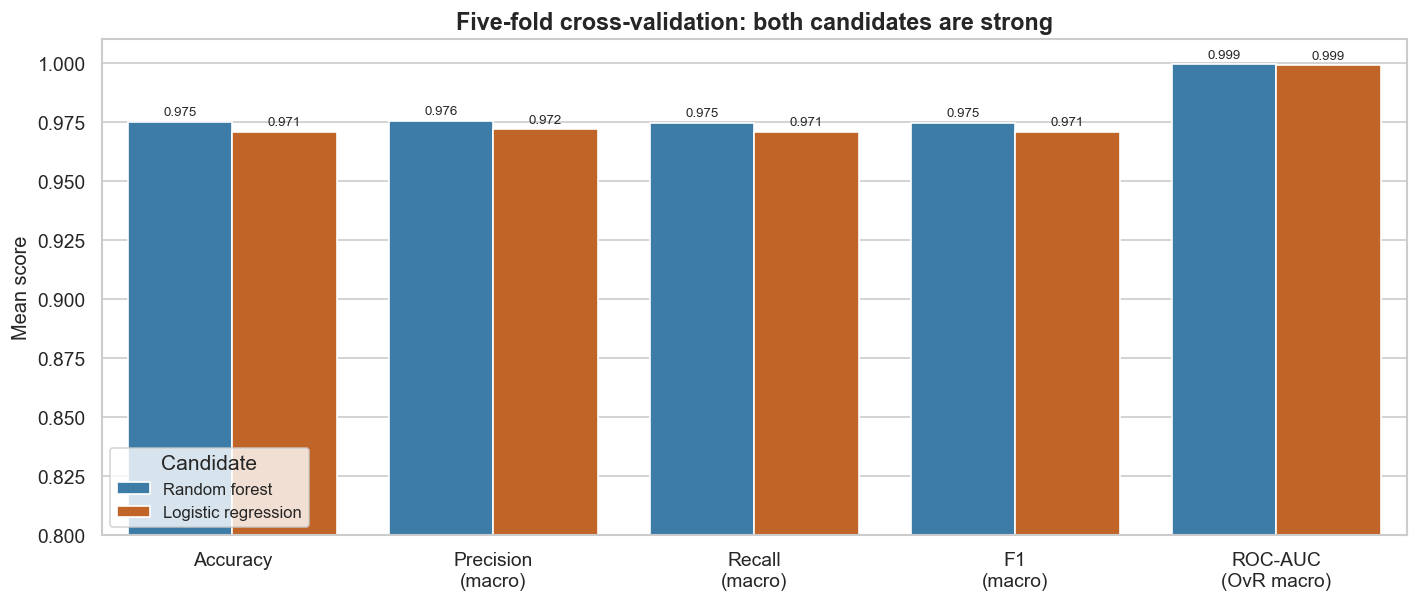

In [14]:
metric_labels = {
    "accuracy": "Accuracy",
    "precision": "Precision\n(macro)",
    "recall": "Recall\n(macro)",
    "f1": "F1\n(macro)",
    "roc_auc": "ROC-AUC\n(OvR macro)",
}
long_cv = []
for _, row in cv_results.iterrows():
    for metric, label in metric_labels.items():
        long_cv.append({"Model": row["model"], "Metric": label, "Mean": row[f"{metric}_mean"], "Std": row[f"{metric}_std"]})
long_cv = pd.DataFrame(long_cv)

fig, ax = plt.subplots(figsize=(12, 5.2))
sns.barplot(data=long_cv, x="Metric", y="Mean", hue="Model", ax=ax, palette=["#2C7FB8", "#D95F0E"], errorbar=None)
for i, (_, r) in enumerate(long_cv.iterrows()):
    # Seaborn orders each hue within each x category; error bars are added below from the plotted data.
    pass
ax.set_ylim(0.80, 1.01)
ax.set(title="Five-fold cross-validation: both candidates are strong", ylabel="Mean score", xlabel="")
ax.legend(title="Candidate")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_cross_validation_comparison.png", bbox_inches="tight")
plt.show()

In [15]:
final_model = models[selected_model_name]
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

test_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "roc_auc_ovr_macro": roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro"),
}
test_metrics_df = pd.DataFrame(
    {"Metric": ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)", "ROC-AUC (OvR macro)"],
     "Held-out test score": list(test_metrics.values())}
)
test_metrics_df["Held-out test score"] = test_metrics_df["Held-out test score"].map("{:.4f}".format)
display(test_metrics_df)

print("\nClassification report (held-out test set):")
print(classification_report(y_test, y_pred, digits=3, zero_division=0))

,Metric,Held-out test score
0,Accuracy,0.9694
1,Precision (macro),0.9700
2,Recall (macro),0.9691
3,F1 (macro),0.9689
4,ROC-AUC (OvR macro),0.9992



Classification report (held-out test set):
              precision    recall  f1-score   support

           0      1.000     0.972     0.986        36
           1      0.923     1.000     0.960        36
           2      1.000     1.000     1.000        35
           3      0.973     0.973     0.973        37
           4      0.973     1.000     0.986        36
           5      1.000     1.000     1.000        37
           6      1.000     0.972     0.986        36
           7      0.923     1.000     0.960        36
           8      0.938     0.857     0.896        35
           9      0.971     0.917     0.943        36

    accuracy                          0.969       360
   macro avg      0.970     0.969     0.969       360
weighted avg      0.970     0.969     0.969       360



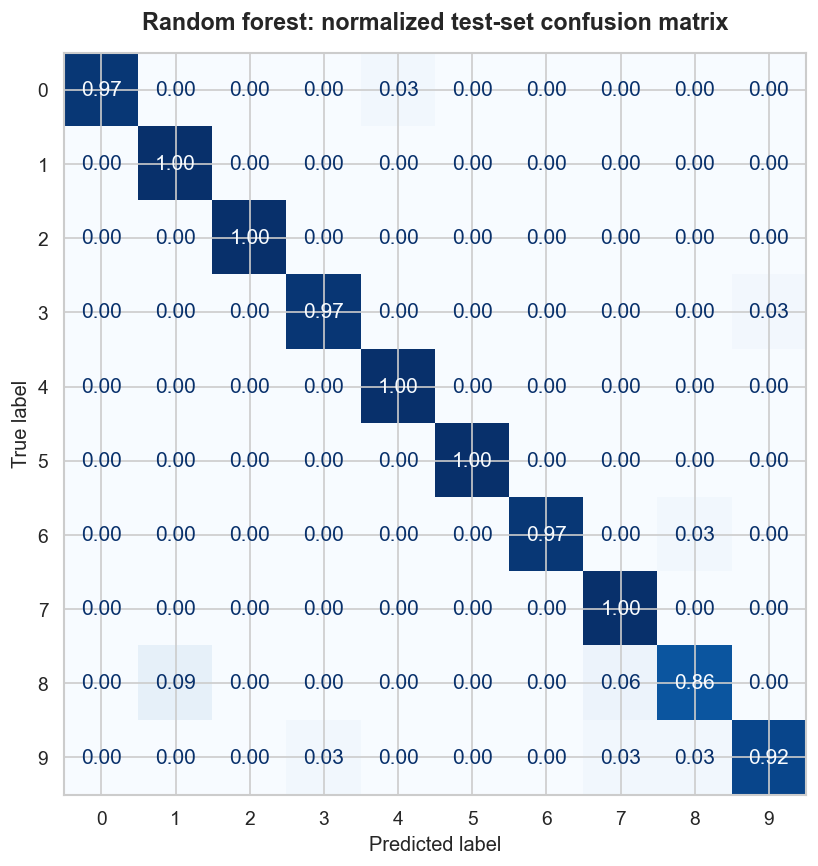

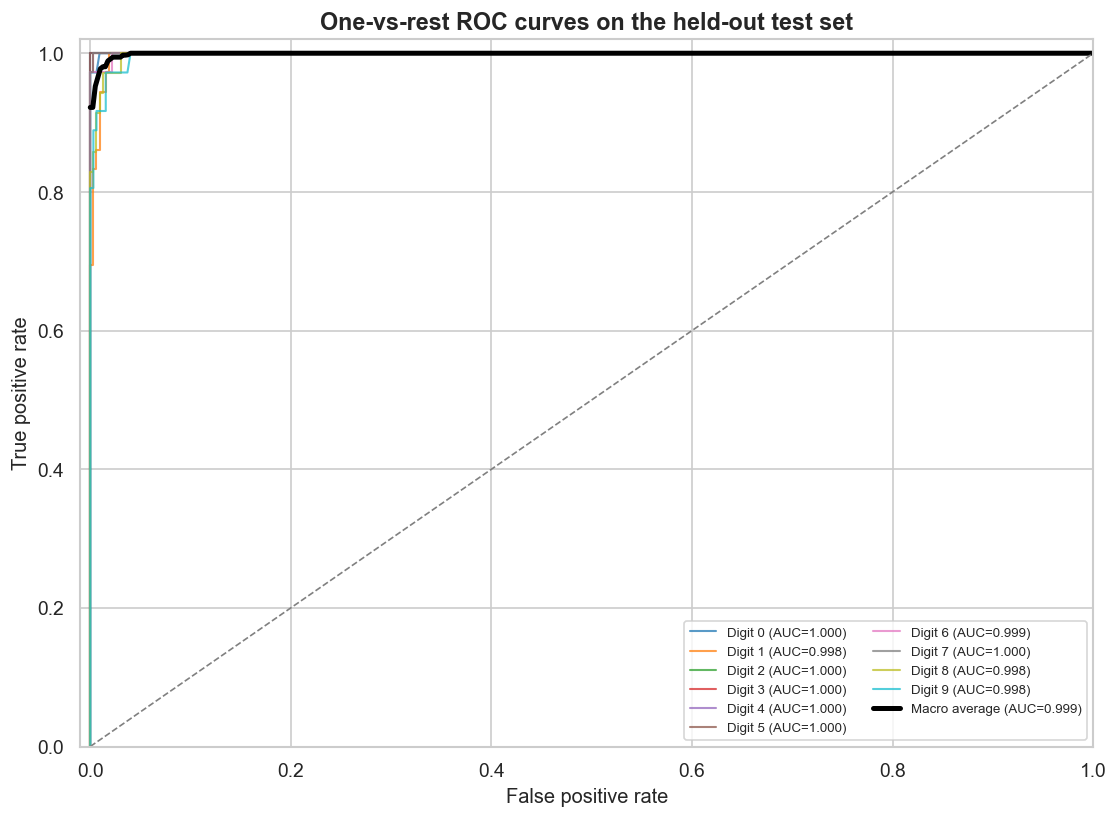

In [16]:
fig, ax = plt.subplots(figsize=(9, 7.4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=class_names, normalize="true", values_format=".2f", cmap="Blues", ax=ax, colorbar=False
)
ax.set_title(f"{selected_model_name}: normalized test-set confusion matrix", pad=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_confusion_matrix.png", bbox_inches="tight")
plt.show()

y_test_binary = label_binarize(y_test, classes=np.arange(10))
palette = sns.color_palette("tab10", 10)
fig, ax = plt.subplots(figsize=(9.5, 7))
fpr_grid = np.linspace(0, 1, 400)
interpolated_tprs = []
for i, color in enumerate(palette):
    fpr, tpr, _ = roc_curve(y_test_binary[:, i], y_proba[:, i])
    interpolated_tprs.append(np.interp(fpr_grid, fpr, tpr))
    ax.plot(fpr, tpr, lw=1.25, alpha=0.74, color=color, label=f"Digit {i} (AUC={auc(fpr, tpr):.3f})")
macro_tpr = np.mean(interpolated_tprs, axis=0)
ax.plot(fpr_grid, macro_tpr, color="black", lw=3, label=f"Macro average (AUC={auc(fpr_grid, macro_tpr):.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1)
ax.set(xlim=(-0.01, 1.0), ylim=(0.0, 1.02), xlabel="False positive rate", ylabel="True positive rate", title="One-vs-rest ROC curves on the held-out test set")
ax.legend(loc="lower right", fontsize=8, ncol=2, frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "05_roc_curves.png", bbox_inches="tight")
plt.show()

,digit,precision,recall,f1,support
0,0,1.000,0.972,0.986,36
1,1,0.923,1.000,0.960,36
2,2,1.000,1.000,1.000,35
3,3,0.973,0.973,0.973,37
4,4,0.973,1.000,0.986,36
5,5,1.000,1.000,1.000,37
6,6,1.000,0.972,0.986,36
7,7,0.923,1.000,0.960,36
8,8,0.938,0.857,0.896,35
9,9,0.971,0.917,0.943,36


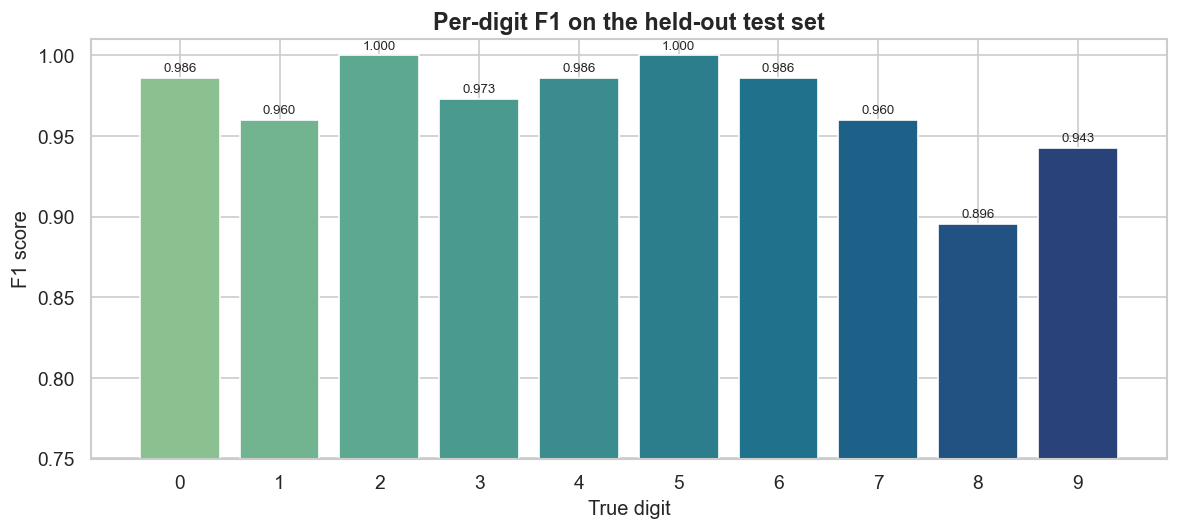

In [17]:
per_precision, per_recall, per_f1, per_support = precision_recall_fscore_support(
    y_test, y_pred, labels=np.arange(10), zero_division=0
)
per_class_metrics = pd.DataFrame(
    {
        "digit": np.arange(10),
        "precision": per_precision,
        "recall": per_recall,
        "f1": per_f1,
        "support": per_support,
    }
)
display(per_class_metrics.style.format({"precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}"}))
per_class_metrics.to_csv(ARTIFACT_DIR / "per_class_metrics.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 4.6))
bars = ax.bar(per_class_metrics["digit"].astype(str), per_class_metrics["f1"], color=sns.color_palette("crest", 10), edgecolor="white")
ax.set(ylim=(0.75, 1.01), xlabel="True digit", ylabel="F1 score", title="Per-digit F1 on the held-out test set")
ax.bar_label(bars, labels=[f"{v:.3f}" for v in per_class_metrics["f1"]], padding=2, fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "06_per_class_f1.png", bbox_inches="tight")
plt.show()

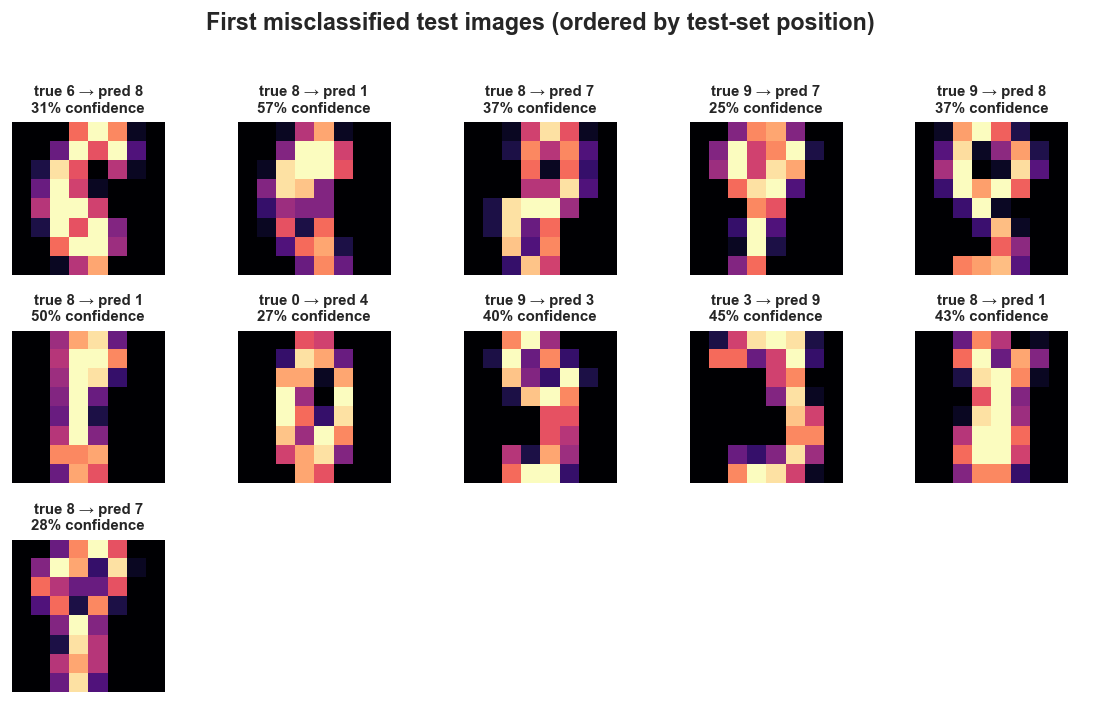

,true,predicted,count
0,8,1,3
1,8,7,2
2,0,4,1
3,3,9,1
4,6,8,1
5,9,3,1
6,9,7,1
7,9,8,1


In [18]:
error_idx = np.flatnonzero(y_test != y_pred)
n_to_show = min(15, len(error_idx))
fig, axes = plt.subplots(3, 5, figsize=(9.6, 5.8))
for ax, idx in zip(axes.ravel(), error_idx[:n_to_show]):
    ax.imshow(X_test[idx].reshape(8, 8), cmap="magma", interpolation="nearest")
    confidence = y_proba[idx, y_pred[idx]]
    ax.set_title(f"true {y_test[idx]} → pred {y_pred[idx]}\n{confidence:.0%} confidence", fontsize=9)
    ax.axis("off")
for ax in axes.ravel()[n_to_show:]:
    ax.axis("off")
fig.suptitle("First misclassified test images (ordered by test-set position)", y=1.01, fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "07_misclassified_examples.png", bbox_inches="tight")
plt.show()

mistakes = pd.DataFrame({"true": y_test[error_idx], "predicted": y_pred[error_idx]})
common_confusions = (
    mistakes.value_counts().rename("count").reset_index().sort_values("count", ascending=False).head(8)
)
display(common_confusions)

In [22]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
...

Ellipsis

In [23]:
from pathlib import Path

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
artifacts = {
    "dataset": {"name": "scikit-learn Digits", "n_images": int(len(y)), "image_shape": [8, 8], "n_classes": 10},
    "split": {"training_images": int(len(y_train)), "test_images": int(len(y_test)), "random_state": RANDOM_STATE},
    "selection_rule": "Highest mean 5-fold macro ROC-AUC; macro F1 as tie-breaker",
    "selected_model": selected_model_name,
    "cross_validation": cv_results.round(6).to_dict(orient="records"),
    "test_metrics": {key: round(float(value), 6) for key, value in test_metrics.items()},
    "test_errors": int(len(error_idx)),
    "test_error_rate": round(float(1 - test_metrics["accuracy"]), 6),
    "common_confusions": common_confusions.to_dict(orient="records"),
    "library_versions": {"scikit_learn": sklearn.__version__, "numpy": np.__version__, "pandas": pd.__version__},
}
with open(ARTIFACT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(artifacts, f, indent=2)

print("Analysis complete.")
print(f"Selected model: {selected_model_name}")
print(f"Held-out macro ROC-AUC: {test_metrics['roc_auc_ovr_macro']:.4f}")
print(f"Held-out macro F1: {test_metrics['f1_macro']:.4f}")

Analysis complete.
Selected model: Random forest
Held-out macro ROC-AUC: 0.9992
Held-out macro F1: 0.9689
